<a href="https://colab.research.google.com/github/Jatin-Virmani/ML-Colabs/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM

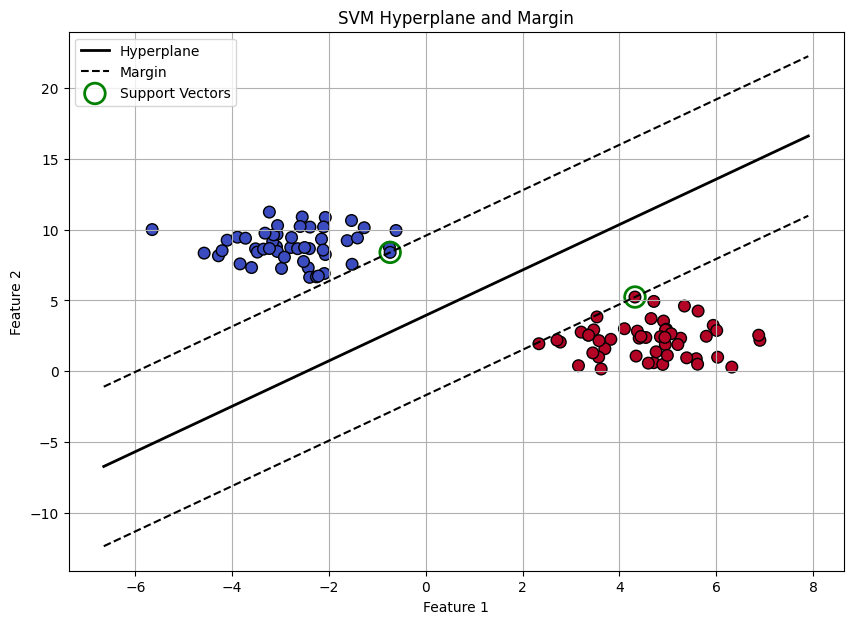

Hyperplane equation:
0.285x1 + -0.178x2 + 0.700 = 0
Margin width = 5.961


In [3]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

# 1. Create sample 2D classification data
X, y = make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=1.2
)

# 2. Train Linear SVM
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

# 3. Extract hyperplane parameters
w = model.coef_[0]
b = model.intercept_[0]

# Slope and intercept for plotting
slope = -w[0] / w[1]
intercept = -b / w[1]

# Margin lines:
# w.x + b = +1
# w.x + b = -1

# 4. Plot Data Points
plt.figure(figsize=(10, 7))
plt.scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap='coolwarm',
    s=70,
    edgecolors='k'
)

# 5. Plot Hyperplane and Margins
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)

# Main hyperplane
y_vals = slope * x_vals + intercept

# Upper margin: w.x + b = 1
y_margin_up = slope * x_vals + (1 - b) / w[1]

# Lower margin: w.x + b = -1
y_margin_down = slope * x_vals + (-1 - b) / w[1]

plt.plot(x_vals, y_vals, 'k-', linewidth=2, label='Hyperplane')
plt.plot(x_vals, y_margin_up, 'k--', linewidth=1.5, label='Margin')
plt.plot(x_vals, y_margin_down, 'k--', linewidth=1.5)

# 6. Highlight Support Vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=220,
    facecolors='none',
    edgecolors='green',
    linewidths=2,
    label='Support Vectors'
)

# 7. Labels
plt.title("SVM Hyperplane and Margin")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# 8. Print Equation
print("Hyperplane equation:")
print(f"{w[0]:.3f}x1 + {w[1]:.3f}x2 + {b:.3f} = 0")

margin = 2 / np.linalg.norm(w)
print("Margin width =", round(margin, 3))